# Exercício 6 — Indicadores, visualização e storytelling (Projeto 2)

Este exercício continua o **Projeto 2**. Ele pega a tabela-resumo por hashtag que você já construiu na Aula 5 (com a sua própria coleta, ou o recorte que você escolheu) e acrescenta pelo menos **duas visualizações** a essa análise.

Siga as partes em ordem: cada uma depende do resultado da anterior. Onde houver `# complete aqui`, é o trecho que falta você escrever; o resto já está pronto.

## Preparação do ambiente

Como este notebook mora numa pasta própria (dentro da sua pasta de entregas), use o `.venv` da **raiz do seu repositório de trabalhos** (o mesmo das outras entregas). Não precisa criar um `.venv` novo dentro de `exercicios/`.

Na raiz do repositório de trabalhos, instale as dependências deste exercício (precisa de `pandas` e `matplotlib`):

```cmd
uv pip install -r projetos/05-metricas-exploracao/exercicios/requirements.txt
```

(Ajuste o caminho se a pasta da entrega tiver outro nome. Se você copiou a pasta `exercicios/` da Aula 6, o arquivo é o `requirements.txt` que veio junto dela.)

Se o `uv` não funcionar, use `pip install -r ...` com o ambiente já ativado.


## Parte 0 — Dados e pergunta

**Fonte dos dados:** copie a mesma coleta (ou recorte) que você usou no exercício da Aula 5 pra `dados/exportacao.csv` dentro desta pasta. Se você já tem `dados/resumo_hashtags.csv` salvo do exercício anterior, pode reaproveitar, mas o roteiro abaixo refaz a tabela do zero pra garantir que está tudo atualizado.

**Pergunta que a visualização vai responder:** você já tinha uma pergunta analítica na Aula 5. Ela pode continuar a mesma, ou você pode escolher uma nova pergunta que fique mais clara com gráfico do que com tabela. Exemplos no espírito desta aula:

- "quais hashtags se destacam em engajamento médio (e quantos posts cada uma teve)?"
- "o engajamento médio variou muito entre os dias da coleta?"
- "contas com mais seguidores têm taxa de engajamento maior ou menor nesta coleta?"

Anote aqui antes de seguir:

**Pergunta escolhida:**

> A quantidade de segudiores do autor do vídeo influencia na quantidade de curtidas dele?

**Por que um gráfico ajuda a responder essa pergunta melhor que a tabela sozinha:**

> Porque ele ajuda a observar se autores com mais seguidores terão necessariamente mais curtidas totais.


## Parte 1 — Carregar e refazer a tabela-resumo

Carregue o CSV e refaça o pipeline da Aula 5/6: remover duplicata, filtrar visualização zero, calcular taxa de engajamento, explodir hashtags e agrupar. Esse trecho já vem pronto, igual ao que foi feito em aula, só ajuste os nomes de coluna se a sua plataforma usar nomes diferentes.

In [1]:
import pandas as pd  # pandas pra tabela
import matplotlib.pyplot as plt  # matplotlib pra gráfico

df = pd.read_csv("dados/exportacao.csv", sep=";")  # lê a exportação
df = df.drop_duplicates()  # remove duplicata, se houver

print(f"Linhas depois de remover duplicatas: {len(df)}")

Linhas depois de remover duplicatas: 640


In [2]:
df_posts = df[df["plays"] > 0].copy()  # só posts com denominador válido (ajuste o nome da coluna se necessário)

df_posts["taxa_engajamento"] = (
    df_posts["likes"] + df_posts["comments"] + df_posts["shares"]
) / df_posts["plays"]  # mesma fórmula da aula: interações dividido por visualizações

print(f"Posts com visualização válida: {len(df_posts)}")

Posts com visualização válida: 640


In [3]:
df_hashtags = df_posts.dropna(subset=["hashtags"]).copy()  # só posts com hashtag preenchida
df_hashtags["hashtags"] = df_hashtags["hashtags"].str.split(",")  # separa a string em lista
df_hashtags = df_hashtags.explode("hashtags")  # uma linha por hashtag
df_hashtags["hashtags"] = df_hashtags["hashtags"].str.strip().str.lower()  # tira espaço e padroniza minúsculas

resumo_hashtags = df_hashtags.groupby("hashtags").agg(  # agrupa por hashtag
    qtd_posts=("id", "count"),
    curtidas_medias=("likes", "mean"),
    engajamento_medio=("taxa_engajamento", "mean"),
).reset_index().sort_values("engajamento_medio", ascending=False)

resumo_hashtags


,hashtags,qtd_posts,curtidas_medias,engajamento_medio
504,rock,1,7817.0,0.251505
377,major,1,7817.0,0.251505
350,joiasdobairo,1,7817.0,0.251505
16,alextelles,1,2746.0,0.248435
634,ídolo,1,2746.0,0.248435
...,...,...,...,...
111,cervejaartesanal,1,7.0,0.006932
554,tailândia,1,5.0,0.006129
164,culináriatailandesa,1,5.0,0.006129
185,delivery,1,5.0,0.006129


## Parte 2 — Primeira visualização: gráfico de barras

Monte um gráfico de barras comparando `engajamento_medio` entre hashtags (um recorte tipo `.head(10)` ajuda a leitura), no mesmo espírito da Seção 5 da aula: figura com tamanho legível, título informativo, rótulos nos dois eixos e a fonte dos dados escrita no gráfico.

**OBS:** o topo por engajamento médio costuma misturar hashtags com poucos posts. Vale olhar também a coluna `qtd_posts` da tabela antes de interpretar.


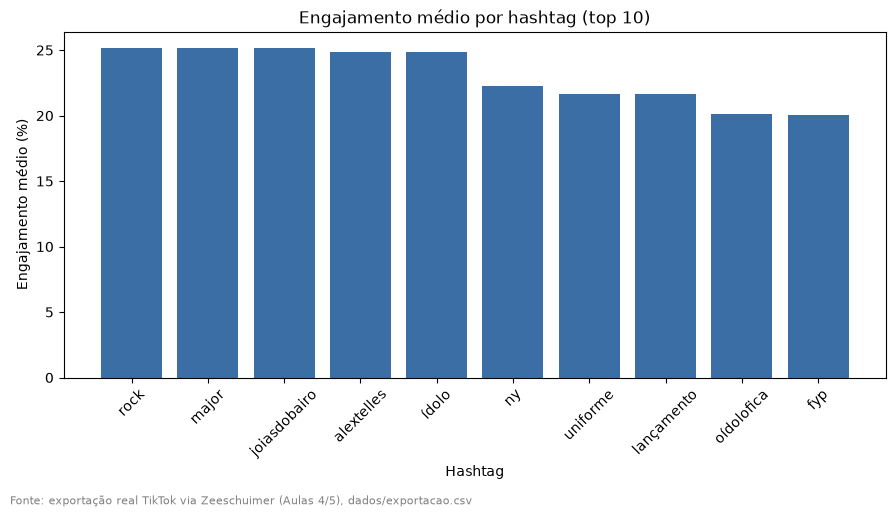

In [4]:
# complete aqui: monte um gráfico de barras com plt.subplots(), comparando uma métrica (ex.: engajamento_medio)
# entre as hashtags de resumo_hashtags (ou um recorte dela, como .head(10))
#
# checklist do gráfico (confira todos antes de seguir):
# - fig, ax = plt.subplots(figsize=(largura, altura))
# - ax.bar(...) com as hashtags no eixo X e a métrica escolhida no eixo Y
# - ax.set_title("...") com um título que descreve o que o gráfico mostra
# - ax.set_xlabel("...") e ax.set_ylabel("...") com nomes claros (e unidade, se fizer sentido)
# - fig.text(...) com a fonte dos dados
# - fig.tight_layout() e plt.show() no final

top10 = resumo_hashtags.head(10)  # as 10 hashtags com maior engajamento médio (a tabela já veio ordenada)

fig, ax = plt.subplots(figsize=(9, 5))  # cria a figura e os eixos, com um tamanho legível

ax.bar(top10["hashtags"], top10["engajamento_medio"] * 100, color="#3b6ea5")  # barra por hashtag; multiplicamos por 100 pra virar porcentagem

ax.set_title("Engajamento médio por hashtag (top 10)")  # título informativo: diz o que o gráfico mostra
ax.set_xlabel("Hashtag")  # rótulo do eixo horizontal
ax.set_ylabel("Engajamento médio (%)")  # rótulo do eixo vertical, com a unidade
ax.tick_params(axis="x", rotation=45)  # gira os nomes das hashtags pra não sobrepor
fig.text(0.01, -0.02, "Fonte: exportação real TikTok via Zeeschuimer (Aulas 4/5), dados/exportacao.csv", fontsize=8, color="gray")  # fonte dos dados, sempre

fig.tight_layout()  # ajusta os espaçamentos pra nada cortar
plt.show()

**Interpretação do gráfico de barras, em texto:**

> O que esse gráfico mostra? Qual hashtag ficou no topo? Quantos posts ela teve (`qtd_posts`)? O que o gráfico **permite** concluir nesta coleta, e o que ele **NÃO** permite (lembre: engajamento médio alto com 1 post não generaliza; volume e desempenho relativo são perguntas diferentes)?

O gráfico mostra as hashtags que tiveram maior engajamento médio. A que ficou no topo foi "rock", ela possui 1 post. Ele permite concluir que a hashtag "rock" possui um engajamento de 25% em 1 post desta coleta, porém não permite concluir que esta hahstag teria o mesmo engajamento em uma coleta diferente.


## Parte 3 — Segunda visualização: linha ou dispersão

Escolha **um** dos dois roteiros abaixo (o que fizer mais sentido pra sua pergunta da Parte 0) e monte o gráfico correspondente. Os dois seguem o que foi feito nas Seções 6 e 7 da aula.


### Opção A — Gráfico de linhas (evolução no tempo)

Use se sua coleta tem posts em datas diferentes e você quer ver o engajamento (ou outra métrica) variar ao longo do tempo.

**OBS:** se a coleta misturar datas muito antigas com datas recentes, o eixo fica esmagado (igual vimos na aula). Nesse caso, filtre o período antes de plotar, comparando `date` com `date` (não com texto):

```python
engajamento_por_dia = engajamento_por_dia[
    engajamento_por_dia["data_coleta"] >= pd.to_datetime("2026-01-01").date()
]
```

(Ajuste a data de corte ao que fizer sentido na **sua** coleta.)


In [8]:
# complete aqui, SE ESCOLHEU a opção A (gráfico de linhas):
# 1. df_posts["data_coleta"] = pd.to_datetime(df_posts["timestamp"]).dt.date
# 2. agrupe por data e calcule a média de taxa_engajamento (ou outra métrica), guarde numa variável nova
# 3. se precisar, filtre o período com pd.to_datetime("AAAA-MM-DD").date() (veja a OBS acima)
# 4. monte o gráfico com plt.subplots(), ax.plot(..., marker="o"), título, rótulos e fonte dos dados
# 5. fig.tight_layout() e plt.show() no final

### Opção B — Gráfico de dispersão (relação entre duas variáveis)

Use se você quer ver a relação entre duas colunas numéricas, um ponto por post. O roteiro da aula foi: **seguidores do autor (`author_followers`) vs. taxa de engajamento (`taxa_engajamento`)**, com escala log no eixo X quando a diferença de tamanho entre contas for enorme.

Outros pares também valem (curtidas vs. comentários, plays vs. engajamento), desde que a pergunta da Parte 0 peça isso.


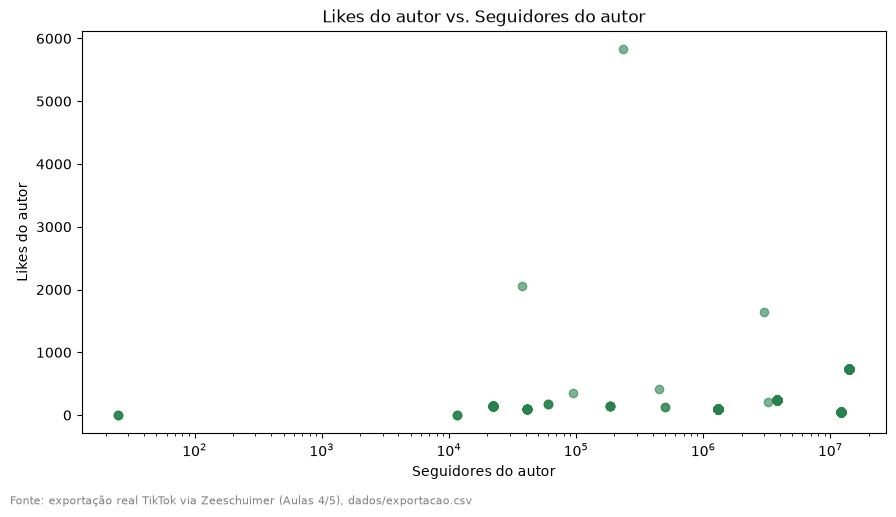

In [28]:
# complete aqui, SE ESCOLHEU a opção B (gráfico de dispersão):
# 1. escolha duas colunas numéricas de df_posts (sugestão da aula: author_followers no X, taxa_engajamento*100 no Y)
# 2. monte com plt.subplots(), ax.scatter(..., alpha=0.6), título, rótulos e fonte dos dados
# 3. se os pontos amontoarem num canto (contas muito diferentes de tamanho), use ax.set_xscale("log")
# 4. fig.tight_layout() e plt.show() no final
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    df_posts["author_followers"],
    df_posts["author_likes"],
    alpha=0.6,  # transparência: ajuda a ver onde os pontos se sobrepõem
    color="#27824c",
)

ax.set_title("Likes do autor vs. Seguidores do autor")  # pergunta que o gráfico responde, no título
ax.set_xlabel("Seguidores do autor")
ax.set_ylabel("Likes do autor")
ax.set_xscale("log") # escala logarítmica: sem ela, as poucas contas gigantes esmagam as pequenas num canto do gráfico
fig.text(0.01, -0.02, "Fonte: exportação real TikTok via Zeeschuimer (Aulas 4/5), dados/exportacao.csv", fontsize=8, color="gray")

fig.tight_layout()
plt.show()


**Interpretação do segundo gráfico, em texto:**

> O que esse gráfico mostra? Qual pergunta ele responde?

> Se foi **linha:** o engajamento variou como ao longo dos dias? Houve pico ou queda? O que o período filtrado (se houver) muda na leitura?

> Se foi **dispersão:** nesta coleta, contas com mais seguidores tendem a engajar mais, menos, ou parecido? A escala log ajudou a ler? O que o gráfico **permite** e o que ele **NÃO** permite (cuidado com causalidade)? 

 Ele mostra a quantidade de likes que um autor receber baseado na quantidade de seguidores dele. Contas com mais seguidores tendem a ter um número de curtidas semelhante ao de contas com menos seguidores. A escala log foi boa para compreender a média de seguidores dos usuários. Ele permite concluir que não é necessariamente a quantidade de seguidores que vai influenciar a quantidade de curtidas totais do autor. Ele não permite concluir que autores com menos seguidores sempre vão ter uma quantidade de curtidas parecida com a de autores com mais seguidores e vice-versa. (o próprio gráfico mostra usuários que "fogem do padrão", ou seja, possuem uma quantidade de seguidores parecida com o resto, porém uma quantidade de curtidas acima da média)


## Parte 4 — Conferir contra a pergunta da Parte 0

Releia a pergunta que você escreveu na Parte 0. Os dois gráficos que você montou respondem essa pergunta? Se a resposta for "só em parte" ou "não", ajuste a pergunta ou o gráfico antes de seguir, não force uma conclusão que os dados não sustentam.

**Resposta final à pergunta, com base nos dois gráficos:**

> Escreva aqui, sem extrapolar além do que os gráficos mostram nesta coleta (sem "sempre", "garante", "causa").
A quantidade de seguidores não influencia, necessariamente, na quantidade de curtidas dele. Como pode ser observado no segundo gráfico, a quantidade de curtidas  dos usuários se mostrou bem parecida no geral, com apenas 3 pontos tendo um resultado mais elevado.


## Parte 5 — Documentação no README

Atualize `projetos/05-metricas-exploracao/README.md` (na sua pasta de entregas, o mesmo README do Projeto 2 que você já tinha da Aula 5) acrescentando:

**Gráfico 1 (barras) — pergunta que ele responde:**

> Quais hashtags possuem uma maior taxa de engajamento?

**Gráfico 2 (linha ou dispersão) — pergunta que ele responde:**

> A quantidade de seguidores do autor influencia na quantidade de curtidas dele?

**Declaração de uso de IA:** não usei IA nesta entrega

**Sobre o csv/entrega:** Na aula 5 foi permitido utilizar o csv disponibilizado pelo professor e na aula 6 não, por conta disso, as perguntas adicionadas acima não correspondem ao exercício da aula 5, então não atualizei o README.md da aula 5 com essas perguntas. Criei uma nova pasta de entrega destinada à aula 6 com os itens relacionados ao meu csv. Além disso, também foi criado um novo README.md na pasta da aula 6 com as mesmas documentações que foram necessárias no README.md da aula 5 + as perguntas que foram pedidas acima, mas que por conta do ocorrido, não correspondem à aula 5 e sim à aula 6.

## Parte 6 — Conferência final

Antes de considerar a entrega concluída, confira:

- [ ] `dados/exportacao.csv` é a mesma coleta (ou recorte) usada no exercício da Aula 5, e a pasta `dados/` está no `.gitignore`.
- [ ] A Parte 1 rodou sem erro e recriou a tabela-resumo por hashtag (com hashtags em minúsculas, se você padronizou).
- [ ] O gráfico de barras da Parte 2 tem título informativo, rótulos nos dois eixos e a fonte dos dados escrita nele.
- [ ] O segundo gráfico da Parte 3 (linha ou dispersão) também tem título, rótulos e fonte; se foi linha com filtro de data, a comparação usou `.date()` (não string solta).
- [ ] As duas interpretações em texto (Partes 2 e 3) dizem o que o gráfico mostra E o que ele não permite concluir.
- [ ] A Parte 4 responde à pergunta da Parte 0 sem extrapolar além da evidência.
- [ ] `projetos/05-metricas-exploracao/README.md` foi atualizado com a pergunta de cada gráfico e a declaração de uso de IA.
- [ ] O notebook roda do início ao fim sem erro usando Kernel → Restart e Run All (ou o equivalente no VS Code), não só célula por célula fora de ordem.
- [ ] Esse notebook está copiado dentro de `projetos/05-metricas-exploracao/` na sua pasta de entregas.
- [ ] Você já fez `git add`, `git commit` e `git push` dessa entrega.
